In [1]:
import os
import time
import numpy as np
import xarray as xr
import matplotlib.pyplot as plt
import matplotlib.gridspec as gridspec

from graphcast.model_utils import dataset_to_stacked

In [2]:
def load_and_stack_model_predictions(config, eval_dates, n_forecast_steps=None):
    """Loads prediction data based on the model's configuration."""
    pred_prefix = config["pred_prefix"]
    
    infer_dir = f"inference_{config['expt']}" if config["expt"] else "inference"
    location = os.path.join(SCRATCH_DIR, config["model_type"], config["run"], f"{infer_dir}/validation/")
    fname = f"{location}/{config['pred_prefix'].lower()}.{config['duration']}.zarr"
    model_pred = xr.open_zarr(fname)

    # subsample
    pred = model_pred.sel(time=slice(eval_dates[0], eval_dates[1])).isel(lead_time=slice(None, n_forecast_steps))

    # stack it
    pred_stacked = dataset_to_stacked(pred, preserved_dims=("time","lead_time","lat","lon"))
    
    return pred_stacked 

In [3]:
def load_and_stack_reference_truth(config, eval_dates, n_forecast_steps=None):
    """Loads reference truth data based on the model's configuration."""
    pred_prefix = config["pred_prefix"]
    
    infer_dir = f"inference_{config['expt']}" if config["expt"] else "inference"
    location = os.path.join(SCRATCH_DIR, config["model_type"], config["run"], f"{infer_dir}/validation/")
    fname = f"{location}/{config['ref_truth'].lower()}.{config['duration']}.zarr"
    ref_pred = xr.open_zarr(fname)

    # subsample
    ref_pred = ref_pred.sel(time=slice(eval_dates[0], eval_dates[1])).isel(lead_time=slice(None, n_forecast_steps))

    # stack it
    ref_pred_stacked = dataset_to_stacked(ref_pred, preserved_dims=("time","lead_time","lat","lon"))
    
    return ref_pred_stacked 

In [4]:
def spatial_cross_covariance(da: xr.DataArray, mask: xr.DataArray, 
                             dim: str = "channels", norm: bool = False):
    """
    Calculates the spatial cross-covariance or cross-correlation matrix for all pairs 
    along dim.

    Args:
        da (xr.DataArray): The input DataArray, which should be loaded into memory.
                           ('time', 'lead_time', 'lat', 'lon', 'channels').
        mask (xr.DataArray): Mask DataArray ("lat", "lon", "channels")
        dim (str): The dimension along which variables are defined (e.g., "channels").
        norm (bool): If true, compute correlation instead of covariance.

    Returns:
        xr.DataArray: A DataArray containing the full covariance or correlation matrix.
    """
    
    n_ic = da.sizes["time"]
    n_leadtimes = da.sizes["lead_time"]
    n_channels = da.sizes["channels"]

    cov_mat = xr.DataArray(np.zeros((n_ic, n_leadtimes, n_channels, n_channels)), 
                           dims=["time", "lead_time", "channels_x", "channels_y"],
                           coords={"time": da.coords["time"].values,
                                   "lead_time":da.coords["lead_time"].values,
                                   "channels_x": da.coords["channels"].values,
                                   "channels_y": da.coords["channels"].values}
                          )

    for i in range(n_ic):
        da_ic = da.isel(time=i)
        
        for j in range(n_leadtimes):
            data = da_ic.isel(lead_time=j)
            data = data*mask
        
            if not norm:
                statistic = "covariance"
                data_mean = data.sum(dim=("lat","lon"))/mask.sum(dim=("lat","lon"))
                data_demeaned = data - data_mean
                da1 = data_demeaned.rename({dim: f"{dim}_x"}).stack(latlon=("lat","lon"))
                da2 = data_demeaned.rename({dim: f"{dim}_y"}).stack(latlon=("lat","lon"))
                cov_map = xr.dot(da1, da2, dims="latlon") / (mask.sum(dim=("lat","lon"))-1)
                out_matrix = cov_map

            else:
                statistic = "correlation"
                # We first z-score the data and then compute the covariance of the result.
        
                # Calculate mean and sample standard deviation (with ddof=1).
                data_mean = data.sum(dim=("lat","lon"))/mask.sum(dim=("lat","lon"))
                data_squared = (data-data_mean)**2
                data_std = np.sqrt(data_squared.sum(dim=("lat","lon"))/(mask.sum(dim=("lat","lon"))-1))

                # Z-score the data.
                da_zscored = (data - data_mean) / data_std

                # divide by the sum of the mask beforehand to avoid creating a new "channels" dimension 
                da_zscored = da_zscored / np.sqrt(mask.sum(dim=("lat","lon"))-1)

                # The correlation is the covariance of the z-scored data.
                da1 = da_zscored.rename({dim: f"{dim}_x"}).stack(latlon=("lat","lon")).squeeze()
                da2 = da_zscored.rename({dim: f"{dim}_y"}).stack(latlon=("lat","lon")).squeeze()
            
                # The dot product of z-scored data, divided by (n-1), is the correlation map.
                corr_map = xr.dot(da1, da2, dims="latlon")

                # store this to the correct location
                cov_mat[i, j, :, :] = corr_map

    cov_mat.attrs = {"description": f"tendency {statistic}"}
    
    return cov_mat

In [5]:
def plot_correlation(ax,
                     da: xr.DataArray,
                     ticks: tuple = (0, 1, 8, 15, 22, 29),
                     ticklabels: tuple = ("ssh", "so", "temp", "uo", "vo"),
                     title: str = None,
                     cmap: str = "RdBu_r",
                     vmin: float = None,
                     vmax: float = None,
                     add_colorbar: bool = False,
                     cbar_label: str = "",
                    ):
    """A correlation plot """
    cbar_kwargs={}
    if add_colorbar:
        cbar_kwargs['orientation'] = 'vertical'
        cbar_kwargs['pad'] = 0.1
        cbar_kwargs['aspect'] = 20
        cbar_kwargs['shrink'] = 0.9
        cbar_kwargs['label'] = cbar_label
        
    # Plot the heatmap
    p = da.plot(ax=ax, cmap=cmap, vmin=vmin, vmax=vmax, add_colorbar=add_colorbar, 
                cbar_kwargs=cbar_kwargs)

    # Draw separator lines
    for tick_pos in ticks[1:]:
        line_pos = tick_pos - 0.5
        ax.axvline(line_pos, color='gray', linestyle=':', linewidth=1.5)
        ax.axhline(line_pos, color='gray', linestyle=':', linewidth=1.5)

    # Clean up default axes
    ax.set_xticks([])
    ax.set_yticks([])
    ax.set_xlabel("")
    ax.set_ylabel("")

    # Add custom axis labels
    for i in range(len(ticks) - 1):
        start, end = ticks[i], ticks[i+1]
        midpoint = (start + end - 1) / 2
        label = ticklabels[i].upper() # Use uppercase for clarity

        ax.text(-0.07, midpoint, label, ha='center', va='center', rotation='vertical',
                fontsize=11, transform=ax.get_yaxis_transform(), clip_on=False)
        ax.text(midpoint, -0.07, label, ha='center', va='center',
                fontsize=11, transform=ax.get_xaxis_transform(), clip_on=False)

    if title is not None:
        ax.set_title(title, fontsize=12, pad=10)
    
    return p

In [6]:
# ---- Config ----
EVALUATION_DATES = ("2022-01-01T00", "2022-12-31T18")
FIG_DIR = os.path.join(os.getcwd(), "figures")
SCRATCH_DIR = "/pscratch/sd/n/nagarwal"

MODELS_CONFIG = [
    {
        "name": "Emulator-24h-MSE",
        "type": "emulator",
        "model_type": "ocn-only",
        "run": "R5",
        "expt": "T1M",
        "pred_prefix": "graphufs",
        "ref_truth": "replay", 
        "timestep": "24h",
        "duration": "240h",
        "description": "24hour-mse"
    },
    {
        "name": "Emulator-24h-MLoss",
        "type": "emulator",
        "model_type": "ocn-only",
        "run": "R8",
        "expt": "T2M",
        "pred_prefix": "graphufs",
        "ref_truth": "replay",
        "timestep": "24h",
        "duration": "960h",
        "description": "24hour-maha"
    },
]

# Spatial Correlations

In [7]:
# ---- Reference Truth Spatial Correlations ----
ref_spatial_corr_mat = {}
forecast_days = 10
lead_time_to_plot = 10 # in days

# Consider the first model in the MODELS_CONFIG to 
# get the reference truth forecasts
model_config = MODELS_CONFIG[0]
ref_truth = model_config["ref_truth"]
print(f"\nProcessing {ref_truth} ...")

# Load and stack reference truth forecast once
print("Loading and stacking the data...")
ds = load_and_stack_reference_truth(model_config, EVALUATION_DATES,
                                    n_forecast_steps = forecast_days)
print("Data loading completed successfully!!!")
    
# get the mask
print("Starting mask computation...")
mask = xr.where(ds.isel(time=0, lead_time=0)==0, 0, 1)
print("mask diagnosed!!!")

# compute correlation
print("Computing correlations...")
tic = time.perf_counter()
ref_spatial_corr_mat[ref_truth] = spatial_cross_covariance(ds, mask, 
                                                           dim="channels", 
                                                           norm=True).load()
print("Correlation computed!!!")

print("\n --- All correlations computed!!! ---")
toc = time.perf_counter()

elapsed_time = toc - tic
print(f"Elapsed time: {elapsed_time:0.4f} seconds")


Processing replay ...
Loading and stacking the data...
Data loading completed successfully!!!
Starting mask computation...
mask diagnosed!!!
Computing correlations...
Correlation computed!!!

 --- All correlations computed!!! ---
Elapsed time: 1339.5231 seconds


In [8]:
# ---- Spatial Correlations from Model Predictions ----
all_spatial_corr_mat = {}
forecast_days = 10

# Loop over models
for model_config in MODELS_CONFIG:
    model_name = model_config["name"]
    print(f"\nProcessing Model: {model_name}")

    # Load and stack model prediction data once
    print("Loading and stacking the data...")
    ds = load_and_stack_model_predictions(model_config, EVALUATION_DATES,
                                          n_forecast_steps = forecast_days)
    print("Data loading completed successfully!!!")
    
    # get the mask
    print("Starting mask computation...")
    ds_ref = load_and_stack_reference_truth(model_config, EVALUATION_DATES, 
                                            n_forecast_steps=1)
    mask = xr.where(ds_ref.isel(time=0, lead_time=0)==0, 0, 1)
    print("mask diagnosed!!!")

    
    # compute correlation
    print("Computing correlations...")
    model_name = model_config["name"]
    all_spatial_corr_mat[model_name] = spatial_cross_covariance(ds, mask, dim="channels", norm=True).load()
    print("Correlation computed!!!")

print("\n --- All correlations computed!!! ---")


Processing Model: Emulator-24h-MSE
Loading and stacking the data...
Data loading completed successfully!!!
Starting mask computation...
mask diagnosed!!!
Computing correlations...
Correlation computed!!!

Processing Model: Emulator-24h-MLoss
Loading and stacking the data...
Data loading completed successfully!!!
Starting mask computation...
mask diagnosed!!!
Computing correlations...
Correlation computed!!!

 --- All correlations computed!!! ---


# Plot

In [ ]:
# ---- Plotting 3 in a row ----
nrows = 1
ncols = len(MODELS_CONFIG)+1
lead_time_to_plot = 10 # in days
save_plot = False

fig, ax = plt.subplots(1, ncols, figsize=(6.5*ncols, 5*nrows))

# Panel 1: Reference Truth
corr_spatial_replay = ref_spatial_corr_mat[ref_truth].sel(lead_time=f"{lead_time_to_plot} days").mean("time")
plot_correlation(ax[0], corr_spatial_replay, title=f"Replay", add_colorbar=True, cbar_label="Correlation")

# Panel 2 onwards
for i, key in enumerate(all_spatial_corr_mat.keys()):
    corr_spatial_model = all_spatial_corr_mat[key].sel(lead_time=f"{lead_time_to_plot} days").mean("time")
    plot_correlation(ax[i+1], (corr_spatial_model - corr_spatial_replay)*100/corr_spatial_replay, 
                     title=key, cmap="PRGn_r", vmin=-100, vmax=100, add_colorbar=True, cbar_label="Relative Difference (%)")

plt.tight_layout()

if save_plot:
    plt.savefig(f"./figures/figure4.png", dpi=300)
plt.show()

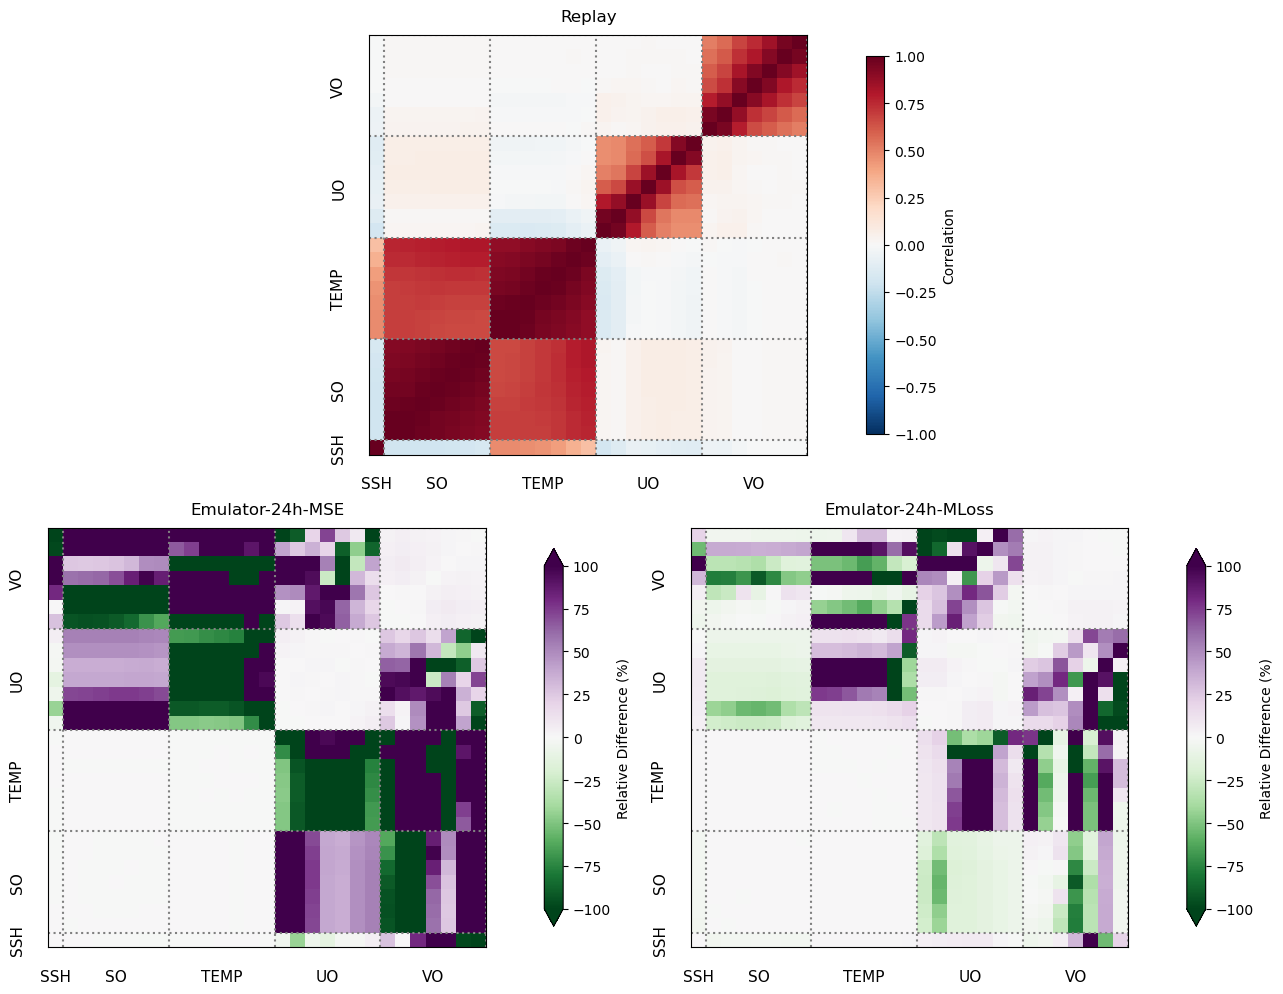

In [11]:
# ---- Plot 2 rows ----
lead_time_to_plot = 10  # in days
save_plot = True

fig = plt.figure(figsize=(13, 10))
gs = gridspec.GridSpec(2, 4, figure=fig)

# Panel 1: Reference Truth; Row 1, middle
ax_top = fig.add_subplot(gs[0, 1:3])

# Panel 2, 3: From the two emulators; Row 2 
ax_bot = [fig.add_subplot(gs[1, :2]), fig.add_subplot(gs[1, 2:])]

# Panel 1: Reference Truth (top row, centered)
corr_spatial_replay = ref_spatial_corr_mat[ref_truth].sel(lead_time=f"{lead_time_to_plot} days").mean("time")
plot_correlation(ax_top, corr_spatial_replay, title="Replay", add_colorbar=True, cbar_label="Correlation")

# Panels 2+: difference panels (bottom row)
for i, key in enumerate(all_spatial_corr_mat.keys()):
    corr_spatial_model = all_spatial_corr_mat[key].sel(lead_time=f"{lead_time_to_plot} days").mean("time")
    plot_correlation(ax_bot[i], (corr_spatial_model - corr_spatial_replay) * 100 / corr_spatial_replay,
                     title=key, cmap="PRGn_r", vmin=-100, vmax=100, add_colorbar=True, cbar_label="Relative Difference (%)")

plt.tight_layout()

if save_plot:
    plt.savefig("./figures/figure4.png", dpi=300)
plt.show()